# Time Series

In [1]:
# -sampling
# -shift
# -rolling window

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
data = pd.read_csv(r'retail_store_sales.csv')
data

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [101]:
data.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='str')

In [102]:
data2 = data[['Transaction Date','Payment Method','Location','Total Spent']]
data2

,Transaction Date,Payment Method,Location,Total Spent
0,2024-04-08,Digital Wallet,Online,185.0
1,2023-07-23,Digital Wallet,Online,261.0
2,2022-10-05,Credit Card,Online,43.0
3,2022-05-07,Credit Card,Online,247.5
4,2022-10-02,Digital Wallet,Online,87.5
...,...,...,...,...
12570,2023-09-03,Credit Card,In-store,152.0
12571,2022-08-12,Cash,Online,58.5
12572,2024-08-24,Cash,Online,140.0
12573,2023-12-30,Cash,Online,84.0


In [103]:
data2.isna().sum()

Transaction Date      0
Payment Method        0
Location              0
Total Spent         604
dtype: int64

In [104]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction Date  12575 non-null  str    
 1   Payment Method    12575 non-null  str    
 2   Location          12575 non-null  str    
 3   Total Spent       11971 non-null  float64
dtypes: float64(1), str(3)
memory usage: 393.1 KB


In [105]:
data2['Transaction Date'] = pd.to_datetime(data2['Transaction Date'])

In [106]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction Date  12575 non-null  datetime64[us]
 1   Payment Method    12575 non-null  str           
 2   Location          12575 non-null  str           
 3   Total Spent       11971 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 393.1 KB


In [107]:
data2.set_index('Transaction Date', inplace=True)

In [108]:
data2.sort_values(by='Transaction Date')

,Payment Method,Location,Total Spent
Transaction Date,,,
2022-01-01,Digital Wallet,In-store,62.5
2022-01-01,Credit Card,Online,75.0
2022-01-01,Cash,In-store,109.5
2022-01-01,Digital Wallet,In-store,75.0
2022-01-01,Credit Card,Online,77.5
...,...,...,...
2025-01-18,Cash,In-store,261.0
2025-01-18,Cash,In-store,70.0
2025-01-18,Credit Card,In-store,62.5


In [109]:
data2.index

DatetimeIndex(['2024-04-08', '2023-07-23', '2022-10-05', '2022-05-07',
               '2022-10-02', '2023-11-30', '2023-06-10', '2024-04-02',
               '2023-04-26', '2024-03-14',
               ...
               '2024-09-06', '2023-05-09', '2023-03-28', '2022-06-11',
               '2024-05-13', '2023-09-03', '2022-08-12', '2024-08-24',
               '2023-12-30', '2022-08-06'],
              dtype='datetime64[us]', name='Transaction Date', length=12575, freq=None)

In [32]:
# sampling is just cerating summary on the basis of daily,weekly ,montly,yearly

In [110]:
# resampling data 
daily_sales = data2.resample('D').agg({'Total Spent':['sum']})
daily_sales

,Total Spent
,sum
Transaction Date,
2022-01-01,1642.5
2022-01-02,1135.5
2022-01-03,823.0
2022-01-04,1117.5
2022-01-05,2227.5
...,...
2025-01-14,1304.0
2025-01-15,934.0


In [222]:
# there MS and ME month start and month end 
monthly_sales = data2.resample('ME').agg({'Total Spent':['min','max','sum']})
monthly_sales

Total Spent                
                         min    max      sum
Transaction Date                            
2022-01-31               6.5  410.0  52911.5
2022-02-28               5.0  410.0  43325.5
2022-03-31               5.0  410.0  40996.0
2022-04-30               5.0  380.0  40442.0
2022-05-31               5.0  410.0  40347.5
2022-06-30               5.0  410.0  42576.0
2022-07-31               6.5  410.0  44471.5
2022-08-31               8.0  410.0  41333.5
2022-09-30               9.5  410.0  46113.5
2022-10-31               5.0  395.0  38355.0
2022-11-30               5.0  410.0  41256.5
2022-12-31               9.5  395.0  38201.0
2023-01-31               5.0  410.0  48052.5
2023-02-28               5.0  410.0  39214.5
2023-03-31               5.0  410.0  38534.5
2023-04-30               5.0  410.0  38905.5
2023-05-31               5.0  410.0  40480.5
2023-06-30               5.0  395.0  42474.0
2023-07-31               5.0  395.0  45632.5
2023-08-31               5.0  410.0  38592.0
2023-09-30               5.0  410.0  41069.0
2023-10-31               5.0  410.0  38322.0
2023-11-30               5.0  395.0  37014.0
2023-12-31               5.0  410.0  43021.0
2024-01-31               5.0  410.0  47908.5
2024-02-29               6.5  395.0  37145.0
2024-03-31               5.0  410.0  42861.5
2024-04-30               6.5  410.0  46271.0
2024-05-31               5.0  410.0  43766.5
2024-06-30               6.5  395.0  44721.0
2024-07-31               5.0  410.0  41405.0
2024-08-31               5.0  410.0  43362.0
2024-09-30               5.0  410.0  42161.5
2024-10-31               5.0  410.0  42736.5
2024-11-30               6.5  410.0  44076.0
2024-12-31               5.0  410.0  48466.5
2025-01-31               6.5  410.0  25548.5

In [223]:
monthly_sales = monthly_sales.reset_index()

In [224]:
monthly_sales.columns

MultiIndex([('Transaction Date',    ''),
            (     'Total Spent', 'min'),
            (     'Total Spent', 'max'),
            (     'Total Spent', 'sum')],
           )

In [225]:
monthly_sales.columns =[
    'Transaction Date',
    'Max_sales',
    'Min_sales',
    'total_sales',
]

In [226]:
monthly_sales

,Transaction Date,Max_sales,Min_sales,total_sales
0,2022-01-31,6.5,410.0,52911.5
1,2022-02-28,5.0,410.0,43325.5
2,2022-03-31,5.0,410.0,40996.0
3,2022-04-30,5.0,380.0,40442.0
4,2022-05-31,5.0,410.0,40347.5
5,2022-06-30,5.0,410.0,42576.0
6,2022-07-31,6.5,410.0,44471.5
7,2022-08-31,8.0,410.0,41333.5
8,2022-09-30,9.5,410.0,46113.5
9,2022-10-31,5.0,395.0,38355.0


In [227]:
monthly_sales.isna().sum()

Transaction Date    0
Max_sales           0
Min_sales           0
total_sales         0
dtype: int64

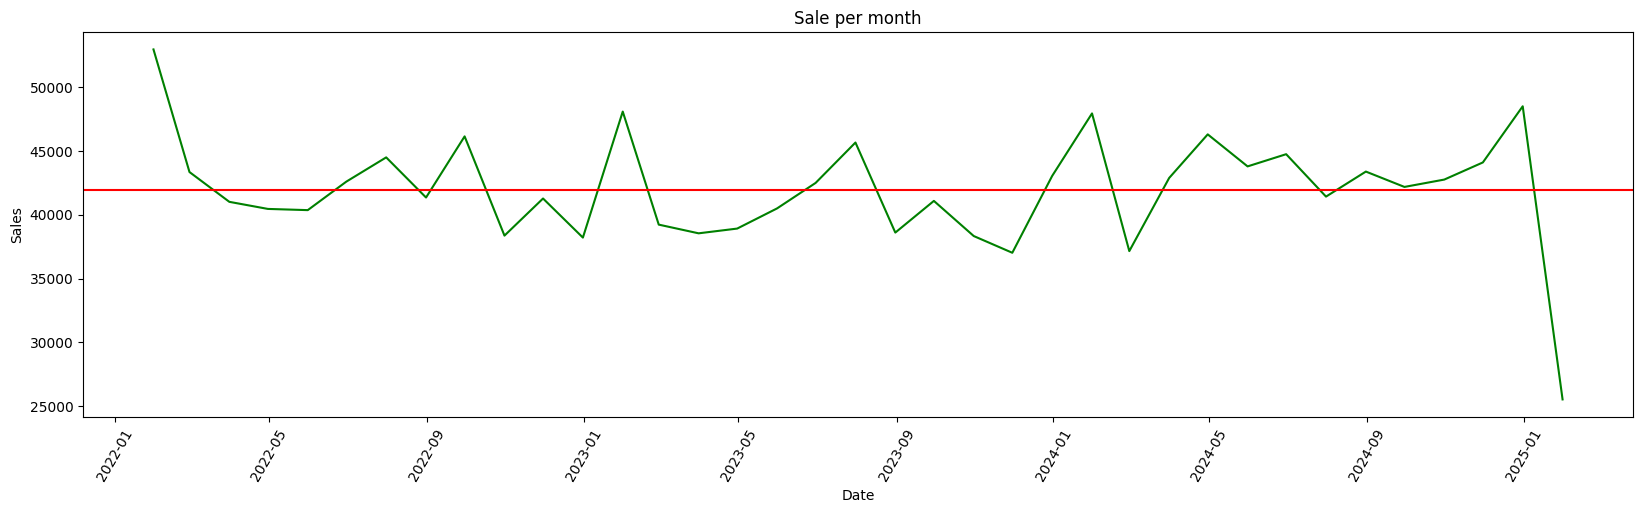

In [233]:
plt.figure(figsize=(20,5))
sns.lineplot(x='Transaction Date',y='total_sales',data=monthly_sales,color='green')
plt.title("Sale per month")
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=60)
plt.axhline(monthly_sales['total_sales'].mean(),color='red')

In [112]:
quarter_sales = data2.resample('QE').agg({'Total Spent':['min','max']})
quarter_sales

Total Spent       
                         min    max
Transaction Date                   
2022-03-31               5.0  410.0
2022-06-30               5.0  410.0
2022-09-30               6.5  410.0
2022-12-31               5.0  410.0
2023-03-31               5.0  410.0
2023-06-30               5.0  410.0
2023-09-30               5.0  410.0
2023-12-31               5.0  410.0
2024-03-31               5.0  410.0
2024-06-30               5.0  410.0
2024-09-30               5.0  410.0
2024-12-31               5.0  410.0
2025-03-31               6.5  410.0

In [164]:
# yearly_sales = data2.resample('YE').agg({'Total Spent':['min','max']})
yearly_sales = data2.resample('YE').agg({'Total Spent':['sum','max','min']})
yearly_sales

Total Spent            
                         sum    max  min
Transaction Date                        
2022-12-31          510329.5  410.0  5.0
2023-12-31          491312.0  410.0  5.0
2024-12-31          524881.0  410.0  5.0
2025-12-31           25548.5  410.0  6.5

In [169]:
yearly_sales.columns = [col for col in yearly_sales.columns]
yearly_sales

,"(Total Spent, sum)","(Total Spent, max)","(Total Spent, min)"
Transaction Date,,,
2022-12-31,510329.5,410.0,5.0
2023-12-31,491312.0,410.0,5.0
2024-12-31,524881.0,410.0,5.0
2025-12-31,25548.5,410.0,6.5


In [171]:
yearly_sales.columns

Index([('Total Spent', 'sum'), ('Total Spent', 'max'), ('Total Spent', 'min')], dtype='object')

In [188]:
yearly_sales = yearly_sales.reset_index()

In [189]:
yearly_sales.columns = [
    'Transaction Date',
    'Total_Sales',
    'Sales_Max',
    'Sales_Min'
]

In [190]:
yearly_sales.set_index('Transaction Date', inplace=True)

In [191]:
yearly_sales.sort_values(by='Transaction Date')
yearly_sales

,Total_Sales,Sales_Max,Sales_Min
Transaction Date,,,
2022-12-31,510329.5,410.0,5.0
2023-12-31,491312.0,410.0,5.0
2024-12-31,524881.0,410.0,5.0
2025-12-31,25548.5,410.0,6.5


In [200]:
yearly_sales['shifted']=yearly_sales['Total_Sales'].shift(periods=1)
yearly_sales

,Total_Sales,Sales_Max,Sales_Min,shifted
Transaction Date,,,,
2022-12-31,510329.5,410.0,5.0,NaN
2023-12-31,491312.0,410.0,5.0,510329.5
2024-12-31,524881.0,410.0,5.0,491312.0
2025-12-31,25548.5,410.0,6.5,524881.0


In [204]:
yearly_sales.tail(2)

,Total_Sales,Sales_Max,Sales_Min,shifted
Transaction Date,,,,
2024-12-31,524881.0,410.0,5.0,491312.0
2025-12-31,25548.5,410.0,6.5,524881.0


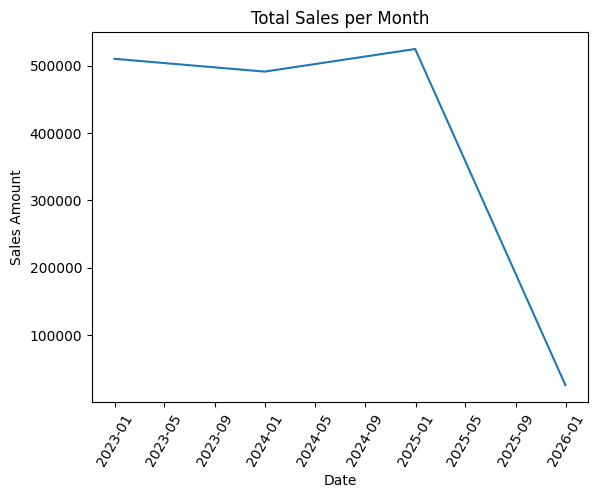

In [203]:
sns.lineplot(x='Transaction Date',y='Total_Sales',data=yearly_sales)
plt.title('Total Sales per Month')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.xticks(rotation=60)
plt.show()